In [1]:
import pandas as pd
import numpy as np
import sklearn
import seaborn as sns
import yellowbrick

print(f'Versión de pandas: {pd.__version__}')
print(f'Versión de numpy: {np.__version__}')
print(f'Versión de scikit-learn (sklearn): {sklearn.__version__}')
print(f'Versión de seaborn: {sns.__version__}')
print(f'Versión de yellowbrick: {yellowbrick.__version__}')

Versión de pandas: 2.2.3
Versión de numpy: 2.2.5
Versión de scikit-learn (sklearn): 1.6.1
Versión de seaborn: 0.13.2
Versión de yellowbrick: 1.5


In [2]:
datos = pd.read_csv ('flights.csv')
datos.shape

(71175, 11)

In [3]:
datos.head()

,flight_id,airline,aircraft_type,schengen,origin,arrival_time,departure_time,day,year,is_holiday,delay
0,26,MM,Airbus A320,non-schengen,TCY,8.885071,10.885071,0,2010,False,70.205981
1,10,YE,Airbus A320,non-schengen,TCY,8.939996,11.939996,0,2010,False,38.484609
2,3,BZ,Embraer E175,schengen,TZF,18.635384,22.635384,0,2010,False,2.388305
3,28,BZ,Airbus A330,non-schengen,EMM,15.967963,17.967963,0,2010,False,19.138491
4,15,BZ,Airbus A330,non-schengen,FJB,16.571894,19.571894,0,2010,False,15.016271


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71175 entries, 0 to 71174
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   flight_id       71175 non-null  int64  
 1   airline         71175 non-null  object 
 2   aircraft_type   71175 non-null  object 
 3   schengen        71175 non-null  object 
 4   origin          71175 non-null  object 
 5   arrival_time    71175 non-null  float64
 6   departure_time  71175 non-null  float64
 7   day             71175 non-null  int64  
 8   year            71175 non-null  int64  
 9   is_holiday      71175 non-null  bool   
 10  delay           71175 non-null  float64
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 5.5+ MB


In [5]:
datos.describe()

,flight_id,arrival_time,departure_time,day,year,delay
count,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000,71175.000000
mean,15.465135,13.283159,16.480222,182.000000,2016.000000,12.548378
std,8.649646,4.023380,4.143705,105.366769,3.741684,23.125349
min,1.000000,7.065594,10.065594,0.000000,2010.000000,-41.028033
25%,8.000000,8.939996,12.668655,91.000000,2013.000000,-4.412876
50%,15.000000,14.258911,16.376052,182.000000,2016.000000,9.740454
75%,23.000000,16.909690,20.041281,273.000000,2019.000000,27.650853
max,30.000000,19.341235,23.341235,364.000000,2022.000000,125.632352


In [6]:
datos.describe(include='O')

,airline,aircraft_type,schengen,origin
count,71175,71175,71175,71175
unique,3,6,2,10
top,BZ,Airbus A320,schengen,TZF
freq,47598,30778,42569,14162


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


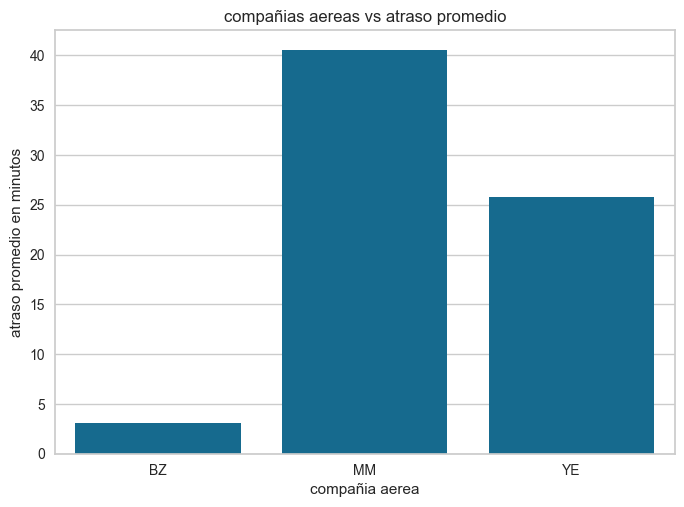

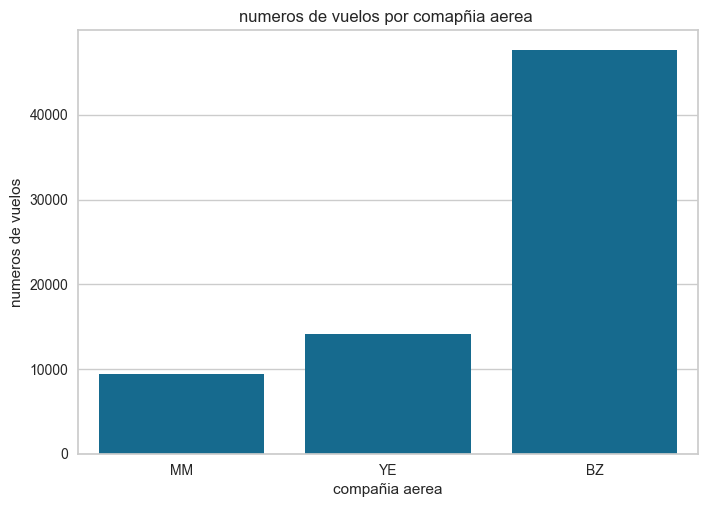

In [8]:
avg_delay = datos.groupby('airline')['delay'].mean().reset_index()
sns.barplot(x='airline', y= 'delay', data=avg_delay)
plt.title('compañias aereas vs atraso promedio')
plt.xlabel('compañia aerea')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='airline')
plt.title('numeros de vuelos por comapñia aerea ')
plt.xlabel('compañia aerea')
plt.ylabel('numeros de vuelos')
plt.show()


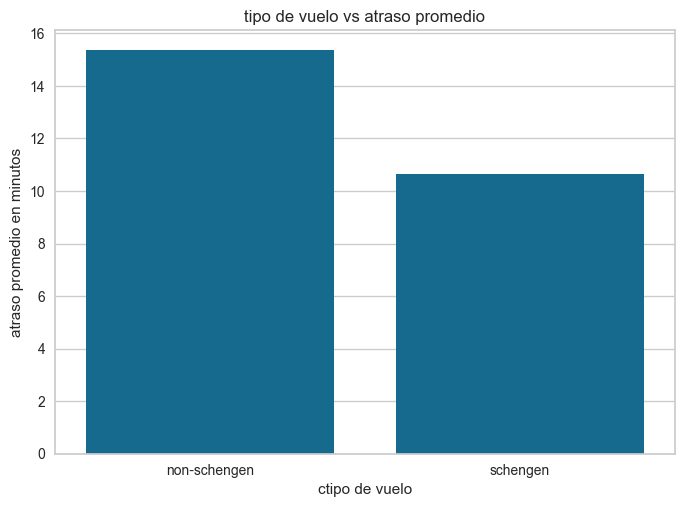

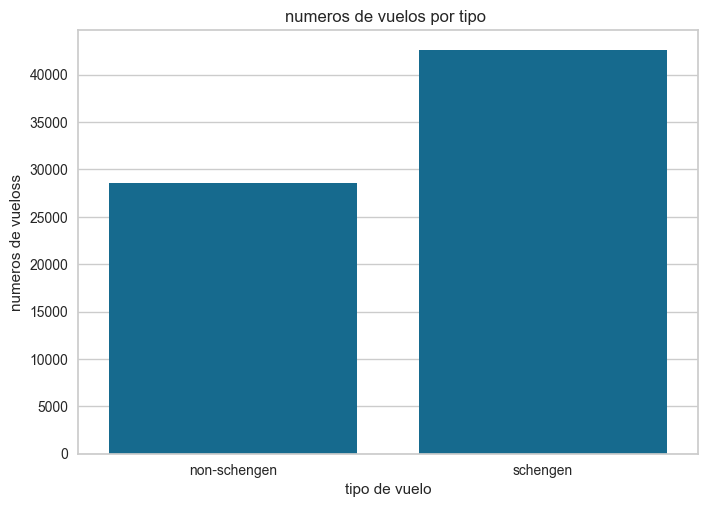

In [ ]:
avg_delay = datos.groupby('schengen')['delay'].mean().reset_index()
sns.barplot(x='schengen', y= 'delay', data=avg_delay)
plt.title('tipo de vuelo vs atraso promedio')
plt.xlabel('tipo de vuelo')
plt.ylabel('atraso promedio en minutos')
plt.show()

sns.countplot(data=datos, x='schengen')
plt.title('numeros de vuelos por tipo ')
plt.xlabel('tipo de vuelo')
plt.ylabel('numeros de vueloss')
plt.show()

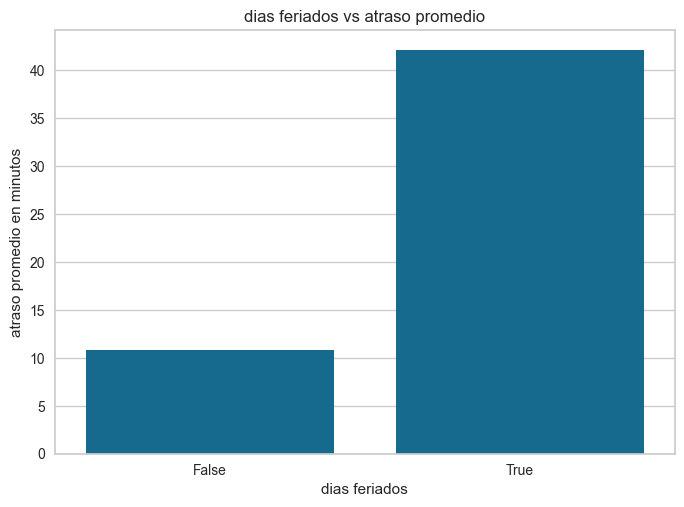

In [10]:
avg_delay = datos.groupby('is_holiday')['delay'].mean().reset_index()
sns.barplot(x='is_holiday', y= 'delay', data=avg_delay)
plt.title('dias feriados vs atraso promedio')
plt.xlabel('dias feriados')
plt.ylabel('atraso promedio en minutos')
plt.show()

In [13]:
order = datos['aircraft_type'].value_counts()#.index
order

#['Airbus A320', 'Airbus A330', 'Boeing 787', 'Embraer E175','Boeing 737', 'Boeing 777']

aircraft_type
Airbus A320     30778
Airbus A330     16654
Boeing 787       9606
Embraer E175     7098
Boeing 737       4722
Boeing 777       2317
Name: count, dtype: int64

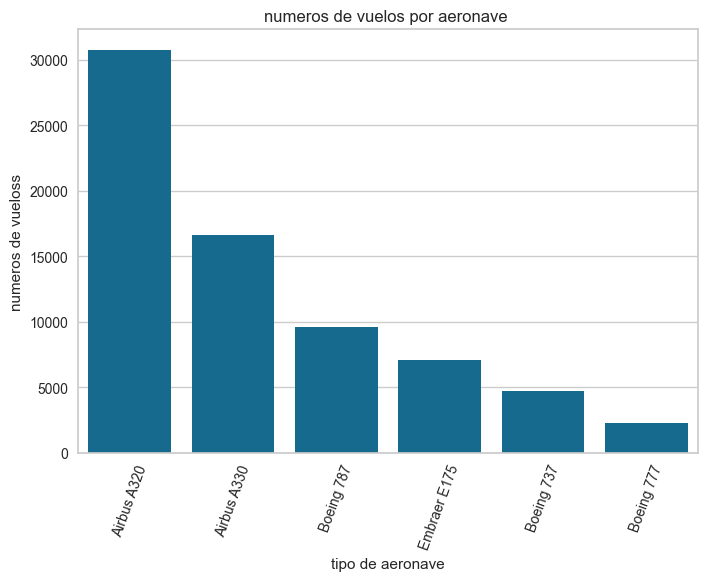

In [14]:
order = datos['aircraft_type'].value_counts().index

sns.countplot(data=datos, x='aircraft_type', order=order)
plt.title('numeros de vuelos por aeronave ')
plt.xticks(rotation=70)
plt.xlabel('tipo de aeronave')
plt.ylabel('numeros de vueloss')
plt.show()